# Serie de tiempo — Total mensual de viajeros internacionales

**Laboratorio 1 — Series de Tiempo (CC3084)**

Este notebook cubre la **serie obligatoria** (Total mensual de viajeros internacionales) para el avance del 23/07/2026:

- División entrenamiento/prueba (70/30, cronológica).
- Construcción de la serie mensual a partir del conjunto de entrenamiento.
- Análisis de la serie: inicio/fin/frecuencia, gráfico, descomposición, estacionariedad en media y varianza, transformación, ACF y prueba de Dickey-Fuller Aumentada.

> Los pasos de selección de parámetros ARIMA, modelos (ARIMA, Prophet, Holt-Winters, suavizamiento exponencial, seasonal naive) y comparación de métricas se completan para la entrega del 26/07/2026, una vez que las demás series (a cargo de otro integrante) estén listas.

> El EDA general del dataset completo vive en `EDA_viajeros.ipynb`. Aquí se retoma el dataframe crudo y se enfoca solo en la construcción y el diagnóstico de esta serie.

## 1. Configuración e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)

DATA_PATH = Path("data/Base_Migracion_2009-2026jun.xlsx")
TRAIN_FRACTION = 0.70  # 70% entrenamiento / 30% prueba, según instrucciones del laboratorio

## 2. Carga y preparación mínima de datos

Se carga la hoja `Datos` del archivo original. La columna `Viajero` es la **cantidad** de viajeros
para esa combinación de Año/Mes/Vía/Frontera/País/Tipo de Viajero (no es una fila por viajero), por
lo que las agregaciones deben hacerse con `sum`, nunca con conteo de filas (`size`/`value_counts`).

Se construye una columna de fecha (`fecha`) a partir de `Año` y `Mes cod`, y se ordena
cronológicamente antes de dividir en entrenamiento/prueba.

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df.columns = [c.strip() for c in df.columns]

# Fecha = primer día del mes correspondiente
df["fecha"] = pd.to_datetime(
    df["Año"].astype(int).astype(str) + "-" + df["Mes cod"].astype(int).astype(str) + "-01",
    format="%Y-%m-%d"
)
df = df.sort_values("fecha").reset_index(drop=True)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
df[["Año", "Mes cod", "Mes", "Tipo de Viajero", "Viajero", "fecha"]].head()

Filas: 161,036 | Columnas: 14
Rango de fechas: 2009-01-01 a 2026-06-01


,Año,Mes cod,Mes,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Turista,1.0,2009-01-01
1,2009,1,Ene,Turista,11.0,2009-01-01
2,2009,1,Ene,Turista,7.0,2009-01-01
3,2009,1,Ene,Turista,2.0,2009-01-01
4,2009,1,Ene,Turista,1.0,2009-01-01


## 3. Decisión de limpieza: definición de "Total de viajeros"

El PDF del laboratorio advierte que, entre 2022 y 2023, la categoría **"Viajero"** (dentro de
`Tipo de Viajero`) cambia de definición: excluye viajeros no turísticos de alta frecuencia
(comercio fronterizo, tránsito). Si se suma **todo** `Tipo de Viajero` sin distinción, la serie total
muestra una caída fuerte en 2023 que **no es una caída real de turismo**, sino un artefacto de
la redefinición.

Por eso, para la serie obligatoria de "Total mensual de viajeros internacionales" se usará
**Turista + Excursionista**, que el PDF indica como consistentes durante todo el período. Se
comprueba esto graficando ambas versiones.

Categorías de Tipo de Viajero: <StringArray>
['Turista', 'Excursionista', 'Viajero', 'Cruceristas']
Length: 4, dtype: str


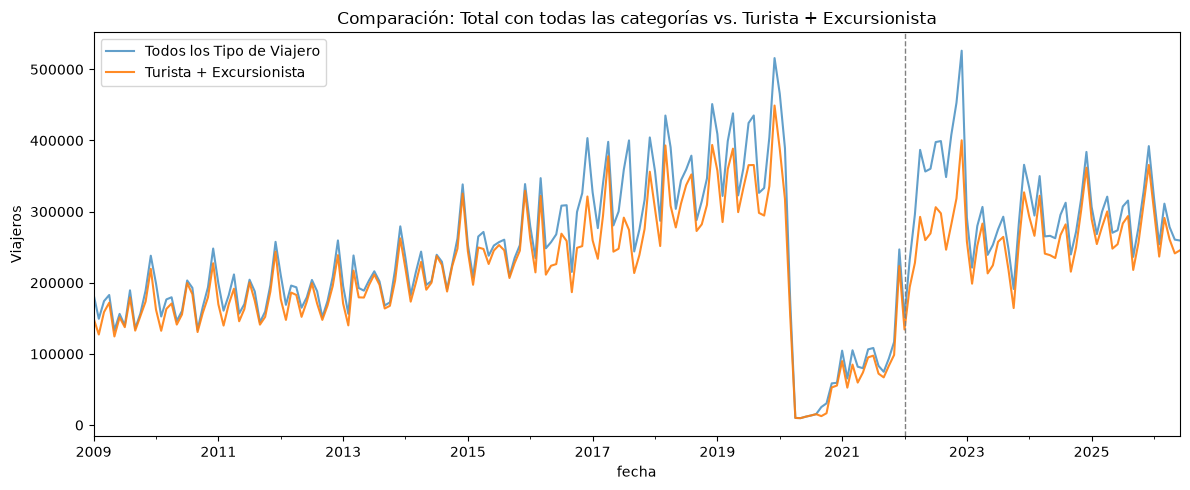

In [3]:
print("Categorías de Tipo de Viajero:", df["Tipo de Viajero"].unique())

CATEGORIAS_CONSISTENTES = ["Turista", "Excursionista"]

todo_mensual = df.groupby(pd.Grouper(key="fecha", freq="MS"))["Viajero"].sum()
consistente_mensual = (
    df[df["Tipo de Viajero"].isin(CATEGORIAS_CONSISTENTES)]
    .groupby(pd.Grouper(key="fecha", freq="MS"))["Viajero"].sum()
)

fig, ax = plt.subplots()
todo_mensual.plot(ax=ax, label="Todos los Tipo de Viajero", alpha=0.7)
consistente_mensual.plot(ax=ax, label="Turista + Excursionista", alpha=0.9)
ax.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle="--", linewidth=1)
ax.set_title("Comparación: Total con todas las categorías vs. Turista + Excursionista")
ax.set_ylabel("Viajeros")
ax.legend()
plt.tight_layout()
plt.show()

## 4. División entrenamiento / prueba (70% / 30%)

Al ser una serie de tiempo, la división **debe ser cronológica** (no aleatoria): el 70% de los
meses más antiguos son entrenamiento y el 30% final es prueba. Mezclar aleatoriamente rompería
la dependencia temporal y permitiría que el modelo "vea el futuro".

In [4]:
meses = consistente_mensual.index
n_train = int(len(meses) * TRAIN_FRACTION)
fecha_corte = meses[n_train - 1]

df_train = df[(df["fecha"] <= fecha_corte) & (df["Tipo de Viajero"].isin(CATEGORIAS_CONSISTENTES))]
df_test = df[(df["fecha"] > fecha_corte) & (df["Tipo de Viajero"].isin(CATEGORIAS_CONSISTENTES))]

print(f"Total de meses: {len(meses)} | Entrenamiento: {n_train} | Prueba: {len(meses) - n_train}")
print(f"Fecha de corte (último mes de entrenamiento): {fecha_corte.date()}")
print(f"Entrenamiento: {df_train['fecha'].min().date()} a {df_train['fecha'].max().date()}")
print(f"Prueba:        {df_test['fecha'].min().date()} a {df_test['fecha'].max().date()}")

Total de meses: 210 | Entrenamiento: 147 | Prueba: 63
Fecha de corte (último mes de entrenamiento): 2021-03-01
Entrenamiento: 2009-01-01 a 2021-03-01
Prueba:        2021-04-01 a 2026-06-01


## 5. Construcción de la serie mensual (serie obligatoria)

Se construye la serie **a partir del conjunto de entrenamiento únicamente**, agregando por mes
(suma de `Viajero`, filtrado a Turista + Excursionista). La serie de prueba se guarda aparte para
usarla en la predicción del 26/07 (inciso 4.i), pero **no se analiza todavía**.

In [5]:
serie_train = df_train.groupby(pd.Grouper(key="fecha", freq="MS"))["Viajero"].sum()
serie_train = serie_train.asfreq("MS")  # asegura frecuencia mensual explícita, sin huecos

serie_test = df_test.groupby(pd.Grouper(key="fecha", freq="MS"))["Viajero"].sum()
serie_test = serie_test.asfreq("MS")

print("Valores faltantes en serie_train tras asfreq('MS'):", serie_train.isna().sum())
serie_train.head()

Valores faltantes en serie_train tras asfreq('MS'): 0


fecha
2009-01-01    149944.029345
2009-02-01    127303.692203
2009-03-01    158795.673819
2009-04-01    172013.467694
2009-05-01    124559.524351
Freq: MS, Name: Viajero, dtype: float64

## 6. Análisis de la serie (entrenamiento)

### 6.a Inicio, fin y frecuencia

In [6]:
print(f"Inicio:     {serie_train.index.min().date()}")
print(f"Fin:        {serie_train.index.max().date()}")
print(f"Frecuencia: {serie_train.index.freqstr} (mensual)")
print(f"N. observaciones: {len(serie_train)}")

Inicio:     2009-01-01
Fin:        2021-03-01
Frecuencia: MS (mensual)
N. observaciones: 147


### 6.b Gráfico de la serie

Se grafica la serie completa y se resalta el período de pandemia (2020-2021) para atender el
punto del rubro sobre el comportamiento durante y después de la pandemia.

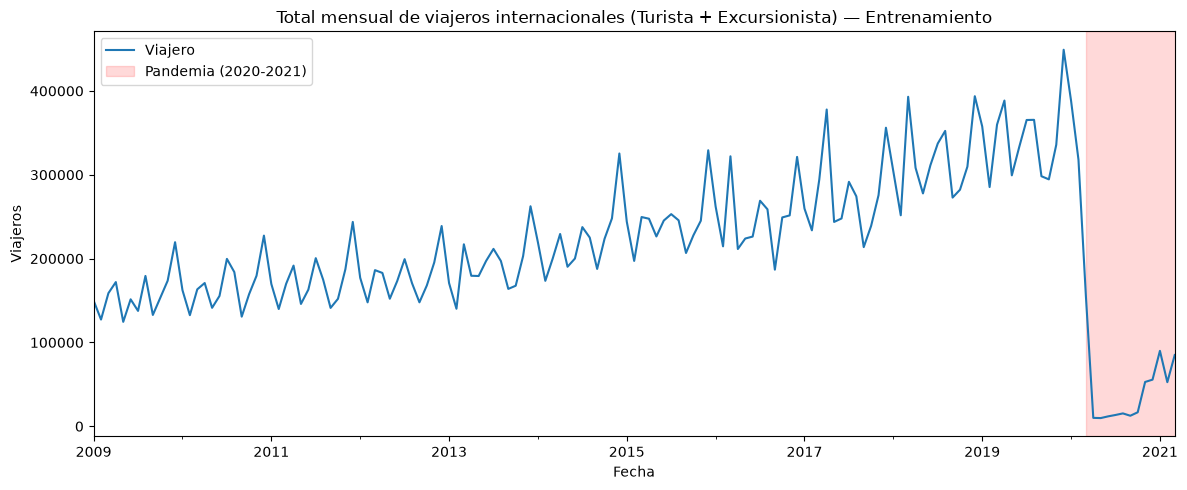

In [7]:
fig, ax = plt.subplots()
serie_train.plot(ax=ax)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"), color="red", alpha=0.15,
           label="Pandemia (2020-2021)")
ax.set_title("Total mensual de viajeros internacionales (Turista + Excursionista) — Entrenamiento")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):** describir a primera vista la tendencia previa a 2020,
la caída abrupta durante la pandemia, la velocidad/forma de la recuperación posterior, y si hay
estacionalidad visible (picos anuales repetidos, ej. temporada alta).

### 6.c Descomposición de la serie

Se usa descomposición **aditiva** y **multiplicativa** (statsmodels, período = 12) para comparar
cuál separa mejor tendencia/estacionalidad/residuo, y para discutir estacionariedad en media
(tendencia) y en varianza (amplitud de la estacionalidad/residuo a lo largo del tiempo).

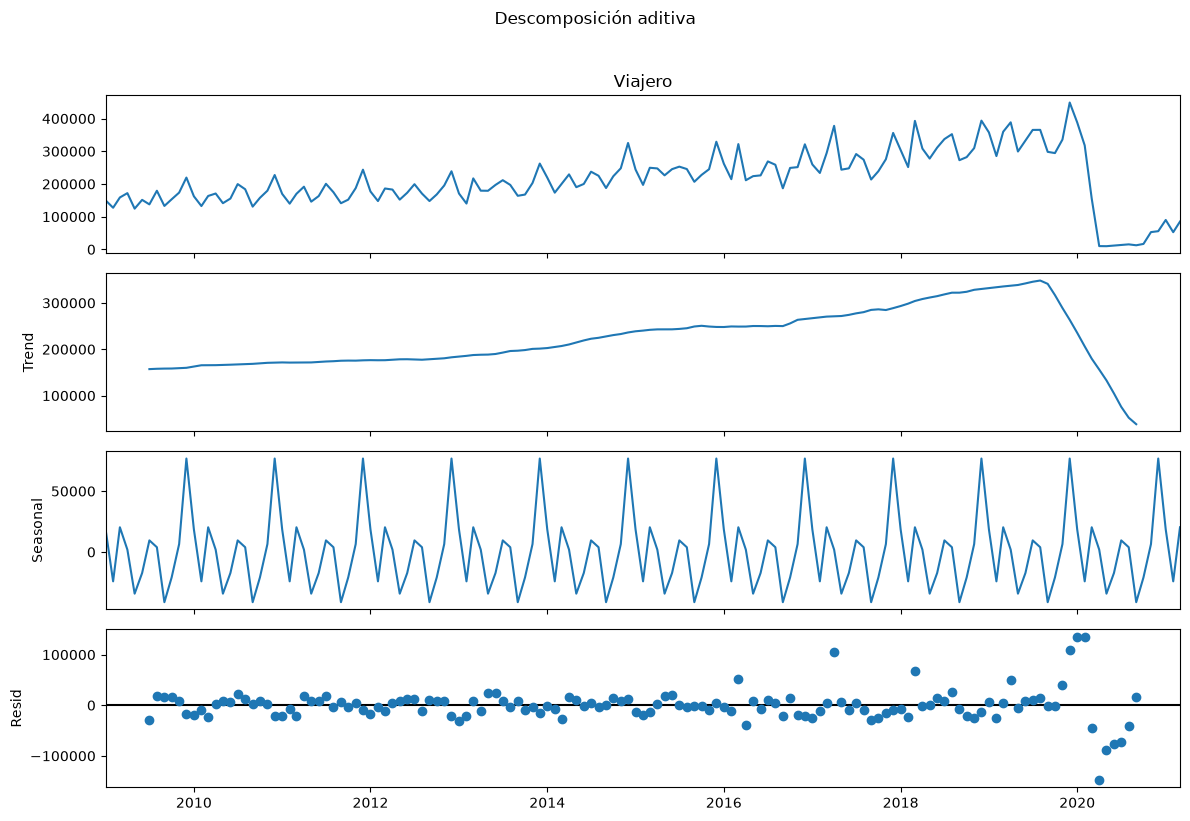

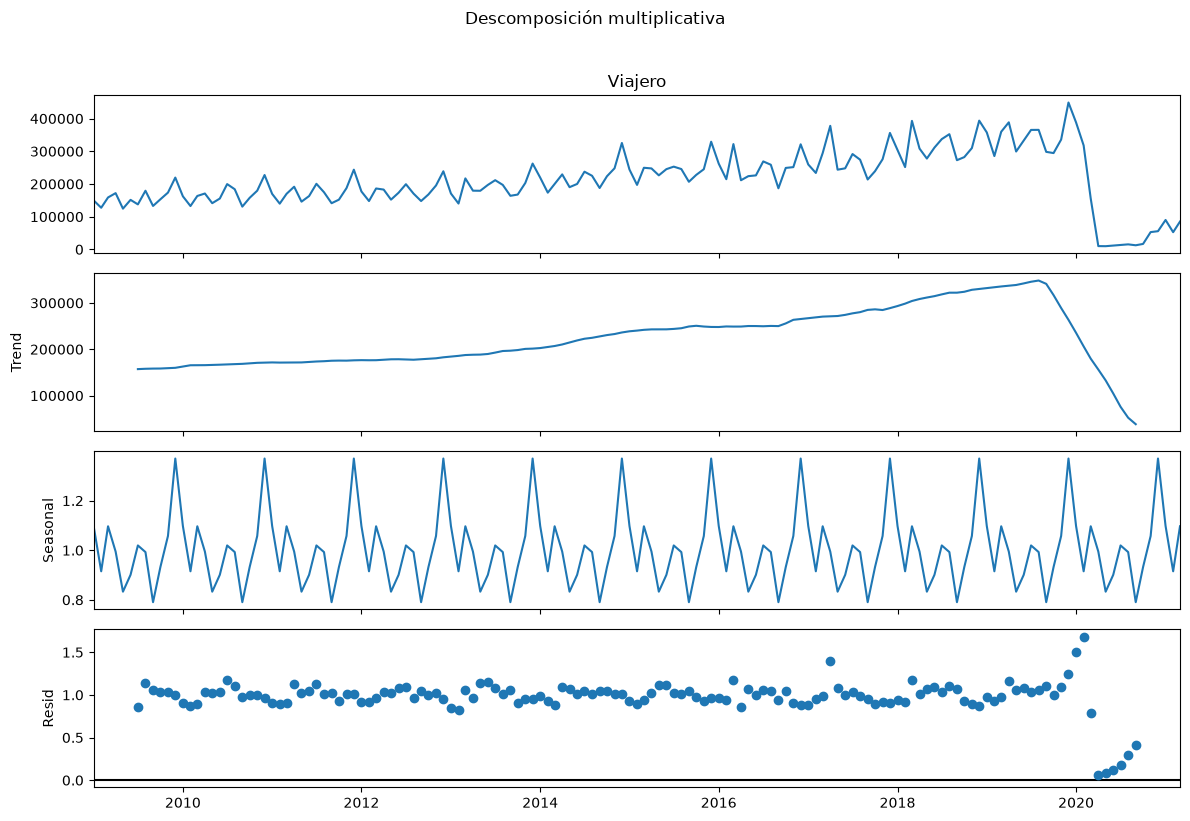

In [8]:
descomp_aditiva = seasonal_decompose(serie_train, model="additive", period=12)
fig = descomp_aditiva.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición aditiva", y=1.02)
plt.tight_layout()
plt.show()

descomp_multiplicativa = seasonal_decompose(serie_train, model="multiplicative", period=12)
fig = descomp_multiplicativa.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición multiplicativa", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):**
- **Estacionariedad en media:** la componente de tendencia ¿es plana o muestra subidas/bajadas
  sostenidas (crecimiento pre-pandemia, caída 2020, recuperación)? Si la tendencia no es plana,
  la serie no es estacionaria en media.
- **Estacionariedad en varianza:** ¿el tamaño de las fluctuaciones estacionales/residuales es
  parecido en todo el período, o es mayor cuando el nivel de la serie es más alto (ej. antes de
  la pandemia vs. durante)? Si la amplitud crece con el nivel, la serie no es estacionaria en
  varianza y la descomposición multiplicativa (o una transformación) es más apropiada que la aditiva.

### 6.d ¿Es necesaria una transformación?

Se compara la serie original con `log(serie)` para evaluar si una transformación logarítmica
estabiliza la varianza (útil cuando la amplitud de las fluctuaciones crece junto con el nivel,
como sugiere la descomposición multiplicativa).

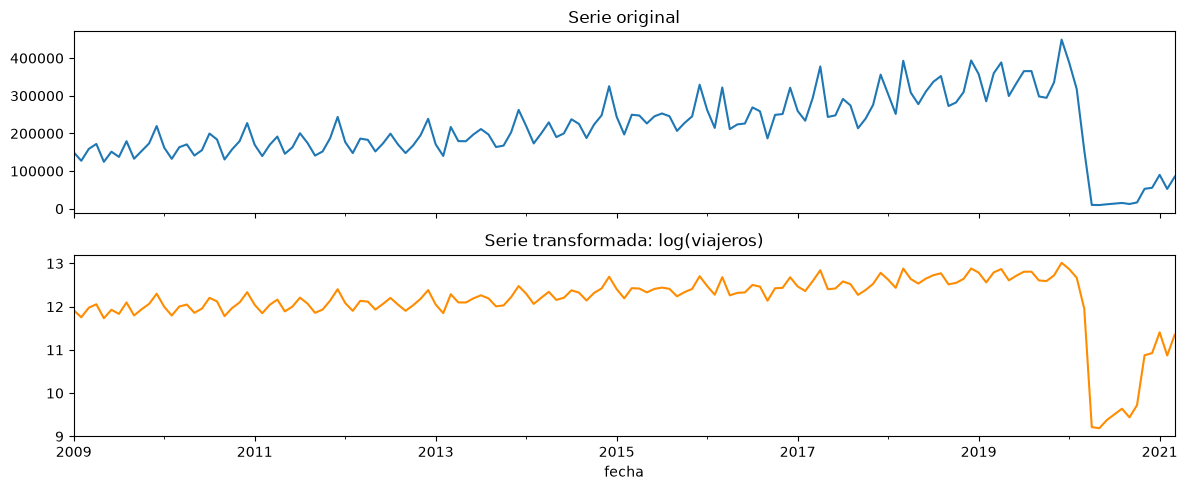

In [9]:
serie_train_log = np.log(serie_train)

fig, axes = plt.subplots(2, 1, sharex=True)
serie_train.plot(ax=axes[0], title="Serie original")
serie_train_log.plot(ax=axes[1], title="Serie transformada: log(viajeros)", color="darkorange")
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):** indicar si `log(viajeros)` reduce visiblemente la
diferencia de amplitud entre el período estable (pre-pandemia) y el período volátil
(pandemia/recuperación). Si sí, se recomienda modelar sobre la serie transformada (log) para
julio 26; si no aporta mejora clara, se mantiene la serie original.

### 6.e Estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

**6.e.i — Gráfico de autocorrelación (ACF).** Un decaimiento lento de la ACF (muchos rezagos
significativos que bajan gradualmente) es evidencia visual de no estacionariedad en media.

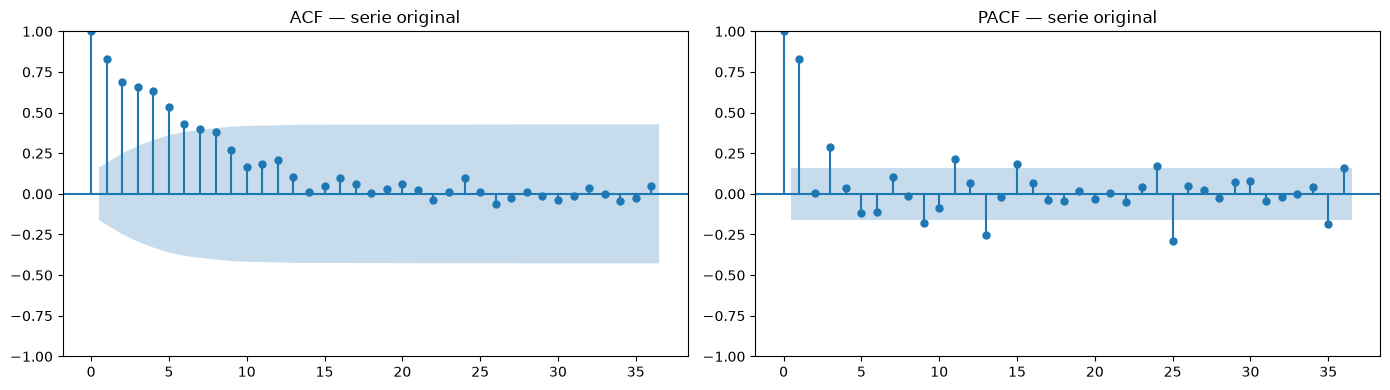

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_train, lags=36, ax=axes[0])
axes[0].set_title("ACF — serie original")
plot_pacf(serie_train, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF — serie original")
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):** describir el patrón de la ACF (decaimiento lento →
no estacionaria en media; picos periódicos cada 12 rezagos → estacionalidad anual) y de la PACF
(rezagos con corte abrupto, útiles más adelante para elegir `p`).

**6.e.ii — Prueba de Dickey-Fuller Aumentada (ADF).** H₀: la serie tiene raíz unitaria (no
estacionaria en media). Si el p-valor > 0.05, no se rechaza H₀ → la serie no es estacionaria en
media y requiere diferenciación.

In [11]:
def prueba_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag="AIC")
    print(f"--- ADF: {nombre} ---")
    print(f"Estadístico ADF: {resultado[0]:.4f}")
    print(f"p-valor:         {resultado[1]:.4f}")
    for clave, valor in resultado[4].items():
        print(f"  Valor crítico {clave}: {valor:.4f}")
    conclusion = "NO estacionaria en media (no se rechaza H0)" if resultado[1] > 0.05 else "Estacionaria en media (se rechaza H0)"
    print(f"Conclusión (alpha=0.05): {conclusion}\n")
    return resultado[1]

p_valor_original = prueba_adf(serie_train, "serie original")
serie_train_diff1 = serie_train.diff().dropna()
p_valor_diff1 = prueba_adf(serie_train_diff1, "primera diferencia")

--- ADF: serie original ---
Estadístico ADF: -2.3644
p-valor:         0.1520
  Valor crítico 1%: -3.4805
  Valor crítico 5%: -2.8835
  Valor crítico 10%: -2.5785
Conclusión (alpha=0.05): NO estacionaria en media (no se rechaza H0)

--- ADF: primera diferencia ---
Estadístico ADF: -2.9875
p-valor:         0.0361
  Valor crítico 1%: -3.4809
  Valor crítico 5%: -2.8837
  Valor crítico 10%: -2.5786
Conclusión (alpha=0.05): Estacionaria en media (se rechaza H0)



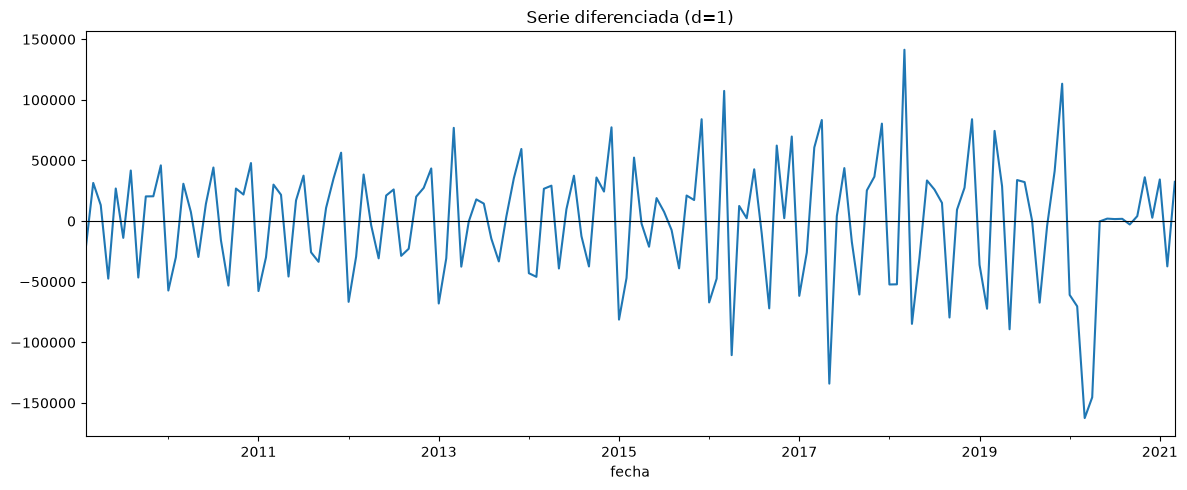

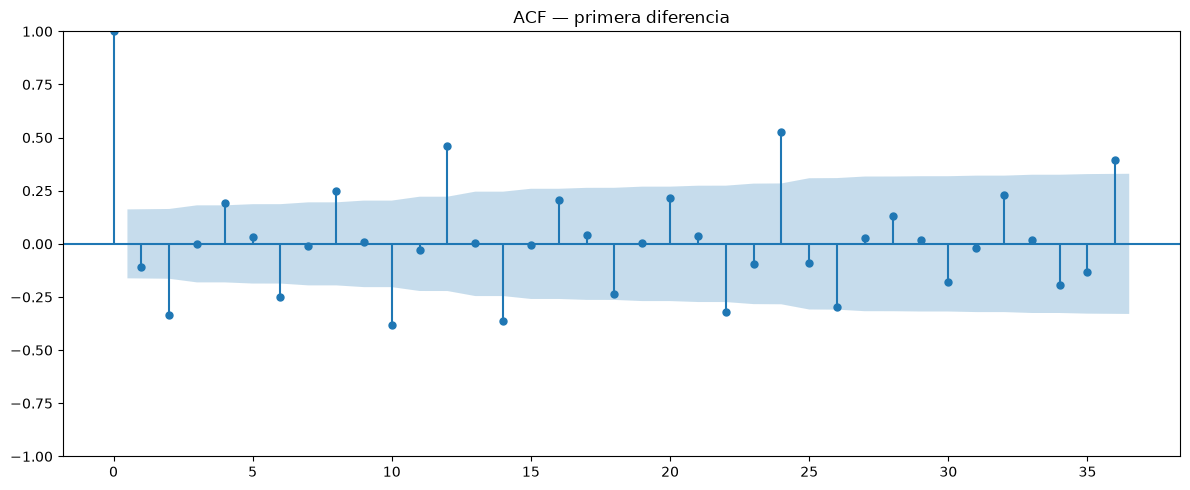

In [12]:
fig, ax = plt.subplots()
serie_train_diff1.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Serie diferenciada (d=1)")
plt.tight_layout()
plt.show()

plot_acf(serie_train_diff1, lags=36)
plt.title("ACF — primera diferencia")
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):** confirmar con el p-valor de la ADF si con una
diferenciación (`d=1`) basta para lograr estacionariedad en media, o si se necesita una
diferenciación adicional (`d=2`) o una diferenciación estacional (rezago 12) dado el patrón anual
observado en la ACF/descomposición. Documentar aquí el valor de `d` que se usará como punto de
partida para el modelo ARIMA.

---

## Próximos pasos (entrega del 26/07/2026)

- Selección de `p`, `q`, `d` con base en ACF/PACF y `pmdarima.auto_arima`, con justificación.
- Ajuste de varios modelos ARIMA, comparación de residuos, AIC/BIC.
- Modelos con Prophet, Holt-Winters, suavizamiento exponencial y seasonal naive.
- Predicción sobre `serie_test` y comparación de modelos con MAE y RMSE.
- Selección del mejor modelo y respuestas del análisis comparativo (inciso 5) una vez estén
  listas las series de las demás categorías.